# SVM Exercises

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

from sklearn import svm
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
from sklearn import metrics

Load Pima diabetes dataset

In [ ]:
url = "https://raw.githubusercontent.com/BeaverWorksMedlytics2020/Data_Public/master/NotebookExampleData/Week1/diabetes.csv"
names = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']

data = pd.read_csv(url, names = names)

Split data into training, colidation, and test sets with a test size of 25%

In [ ]:
X_cols = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']

y_col = 'class'

test_size = 0.2
X_train, X_test, y_train, y_test = train_test_split(data[X_cols], data[y_col], test_size = test_size, random_state = 100)

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size = test_size, random_state = 100)


Create a model with sklearn's SVC and a high gamma value (perhaps 1.0)

In [ ]:
svm_model = SVC(gamma = 0.01, C = 0.6)

svm_model.fit(X_train, y_train)

SVC(C=0.6, gamma=0.01)

Print accuracy of training and validation data

In [ ]:
y_train_pred = svm_model.predict(X_train)
print("Training accuracy is: ", accuracy_score(y_train, y_train_pred)*100, "%")

y_val_pred = svm_model.predict(X_val)
print("Validation accuracy is: ", accuracy_score(y_val, y_val_pred)*100, "%")

Training accuracy is:  89.40936863543789 %
Validation accuracy is:  72.35772357723577 %


Create a model with sklearn's SVC and a low gamma value (perhaps .001)

In [ ]:
svm_model2 = SVC(gamma = 0.001)
svm_model2.fit(X_train, y_train)

SVC(gamma=0.001)

Print accuracy of training and validation data

In [ ]:
y_train_pred2 = svm_model2.predict(X_train)
print("Training accuracy is: ", accuracy_score(y_train, y_train_pred2)*100, "%")

y_val_pred2 = svm_model2.predict(X_val)
print("Validation accuracy is: ", accuracy_score(y_val, y_val_pred2)*100, "%")

Training accuracy is:  84.72505091649694 %
Validation accuracy is:  73.17073170731707 %


Explain the accuracy results below.

After iterating through multiple different training/test splits between 80/20 and 50/50 as well as experimenting with gamma and C constants, the maximum value we were able to achieve seemed to be locked to the low 70s. The training data accuracy would diverge from the high 60s up to 100%, but the validation accuracy seemed locked to ~72-73%.

Print the confusion matrices for your high and low gamma models (both numeric and visualized)

<Figure size 640x480 with 0 Axes>

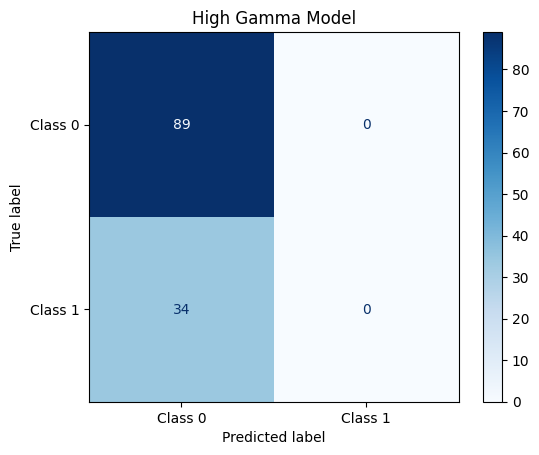

<Figure size 640x480 with 0 Axes>

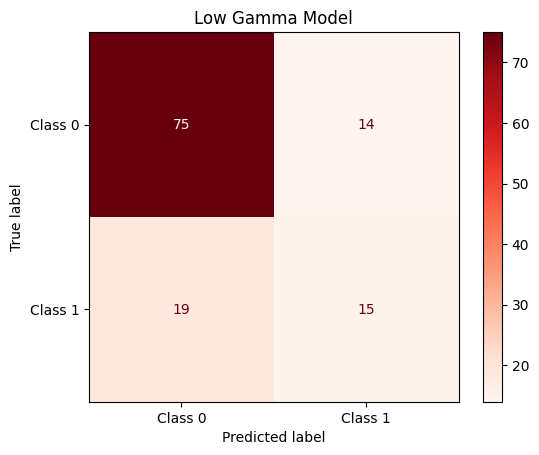

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

plt.figure(1)
cm = confusion_matrix(y_val, y_val_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0', 'Class 1'])
disp.plot(cmap=plt.cm.Blues)
plt.title("High Gamma Model")
plt.show()

plt.figure(2)
cm2 = metrics.confusion_matrix(y_val, y_val_pred2)
disp = metrics.ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=['Class 0', 'Class 1'])
disp.plot(cmap=plt.cm.Reds)
plt.title("Low Gamma Model")
plt.show()
